In [7]:
import pandas as pd
import glob
import os
# name='352'
# long_name='3524m031'
# band='w1'
# table = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_features.csv')
table = pd.read_csv('total_catalogues/w1_var_para_table0.csv')
# table = pd.read_csv('total_catalogues/ztf_wise_Eta_e.csv')

In [35]:
print(len(table))
print(len(table[table['Mean']<12]))
print(len(table[(table['Mean']<12)
                *(table['Std']>0.025)]))

54875027
884228
21840


In [4]:
stripe_table = table[table['dec']<1.5]
stripe_table = stripe_table[stripe_table['dec']>-1.5]

In [9]:
stripe_table = stripe_table[stripe_table['Mean']<16.5]

In [10]:
print(len(stripe_table))

480488


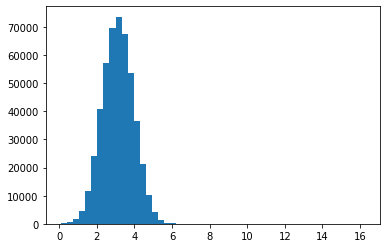

In [12]:
import matplotlib.pyplot as plt
plt.hist(stripe_table['Eta_e'],bins=50)
plt.show()


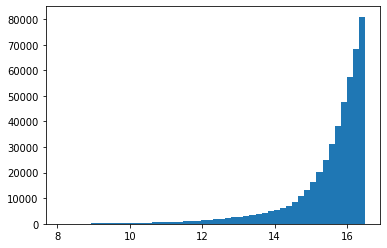

In [19]:
plt.hist(stripe_table['Mean'],bins=50)
plt.show()


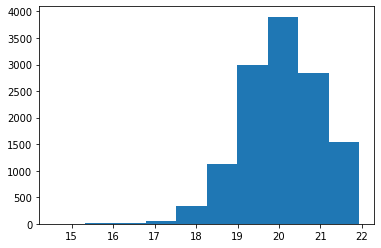

In [90]:
import matplotlib.pyplot as plt

plt.hist(table['Mean_1'])
plt.show()

In [91]:
know_table = pd.read_csv('total_catalogues/ztf_wise_million_quasar.csv')
print(len(know_table))

1405


In [13]:
print(len(know_table[know_table['TYPE']=='K']))

7


In [14]:
print(len(know_table[know_table['TYPE']=='N']))

10


In [81]:
table = pd.read_csv('total_catalogues/ztf_wise_Eta_e.csv')
import matplotlib.pyplot as plt
# table = table[table['Eta_e_1']<1.2e11]
print(len(table))
# plt.hist(table['Eta_e_1'],bins=100)
plt.show()
import numpy as np
log_eta_ztf = np.log10(np.array(table['Eta_e_1']))

12817


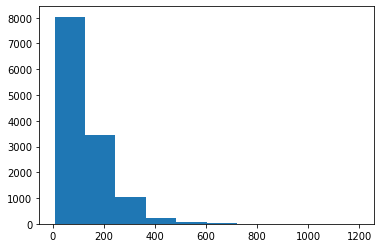

In [83]:
plt.hist(table['Eta_e_2'])
plt.show()

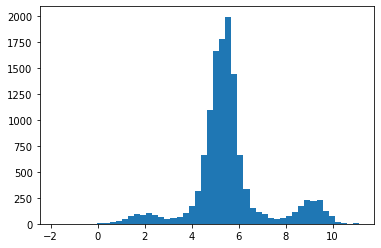

In [87]:
plt.hist(log_eta_ztf,bins=50)
plt.show()

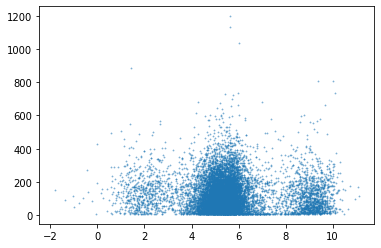

In [82]:
import matplotlib.pyplot as plt
plt.scatter(log_eta_ztf,table['Eta_e_2'],s=1,alpha=0.5,marker='*')

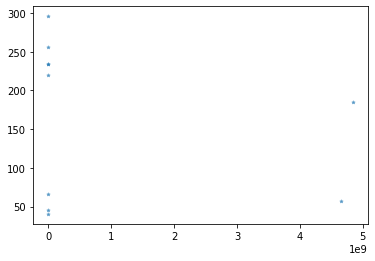

In [86]:
plt.scatter(know_table[know_table['TYPE']=='N']['Eta_e_1'],know_table[know_table['TYPE']=='N']['Eta_e_2'],s=10,alpha=0.5,marker='*')

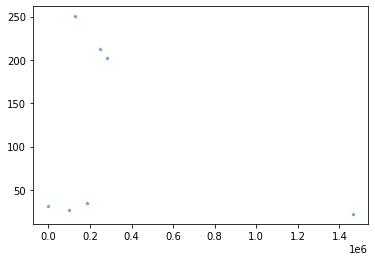

In [69]:
plt.scatter(know_table[know_table['TYPE']=='K']['Eta_e_1'],know_table[know_table['TYPE']=='K']['Eta_e_2'],s=10,alpha=0.5,marker='*')

In [1]:
import pandas as pd
tables = []
for i in (0,1,7,8):
    tables.append(pd.read_csv('total_catalogues/w1_std_pho_match_table%d.csv'%i))
table_std_pho = pd.concat(tables)
# table_std_pho = pd.read_csv('total_catalogues/w1_std_pho_match_table0.csv')

In [2]:
filtered_std_pho = table_std_pho[
    (table_std_pho['median']>13.75) *
    (table_std_pho['median']<14.25)
    ]
print(len(filtered_std_pho))

40373


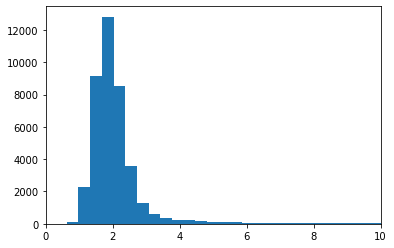

In [3]:
import matplotlib.pyplot as plt 
import numpy as np
plt.hist(np.divide(np.array(filtered_std_pho['Std']),np.array(filtered_std_pho['mean_error'])),bins=100)
plt.xlim(0,10)
plt.show()

(0.0, 10.0)

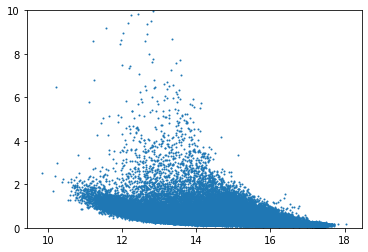

In [21]:
import matplotlib.pyplot as plt 
import numpy as np
SD_divide_sigma = np.divide(np.array(table_std_pho['Std']),
                            np.array(table_std_pho['mean_error'])*6)
plt.scatter(np.array(table_std_pho['median']),SD_divide_sigma,s=1)
plt.ylim(0,10)


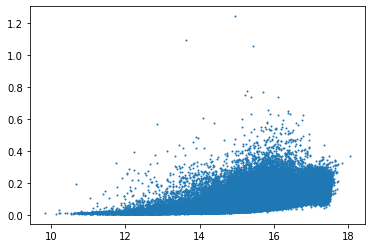

In [9]:
plt.scatter(np.array(table_std_pho['median']),np.array(table_std_pho['Std']),s=1)

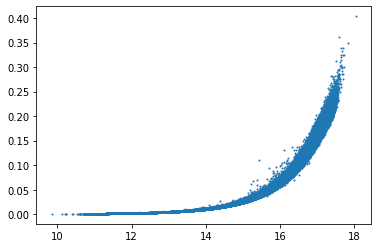

In [10]:
plt.scatter(np.array(table_std_pho['median']),np.array(table_std_pho['mean_error']),s=1)

In [36]:
print(len(table_std_pho[table_std_pho['Mean']<12]))
print(len(table_std_pho[(table_std_pho['Mean']<12)*(table_std_pho['Std']>0.025)]))

2617
39


In [37]:
bright_sources = table_std_pho[(table_std_pho['Mean']<12)*
                               (table_std_pho['Mean']>11.5)]
means = bright_sources['Mean']
mean_errors=bright_sources['mean_error']
stds = bright_sources['Std']

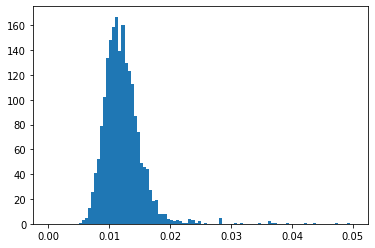

In [38]:
plt.hist(stds,bins=100,range=(0,0.05))
plt.show()

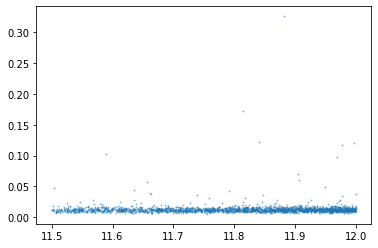

In [39]:
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(means,stds,s=1,alpha=0.5,marker='*')


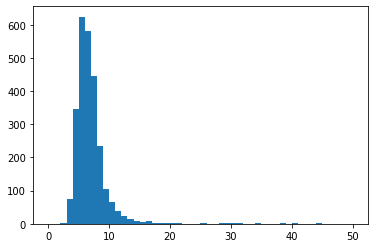

In [10]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(np.divide(stds,mean_errors),bins=50,range=(0,50))
plt.show()

In [8]:
print(bright_sources.columns)

Index(['ra_1', 'dec_1', 'objID', 'gmag', 'e_gmag', 'rmag', 'e_rmag', 'imag',
       'e_imag', 'zmag', 'e_zmag', 'ymag', 'e_ymag', 'col1', 'Unnamed: 0',
       'id_in_matched', 'ra_2', 'dec_2', 'median', 'mean_error', 'Mean',
       'StetsonK', 'Eta_e', 'Std', 'Skew', 'SmallKurtosis', 'Con',
       'Meanvariance', 'Separation'],
      dtype='object')


In [ ]:
bright_sources.to_csv('./total_catalogues/bright_than_12_std_pho.csv')

In [15]:
table_std_pho = table_std_pho[table_std_pho['Mean']<16.5]
len(table_std_pho)

469859

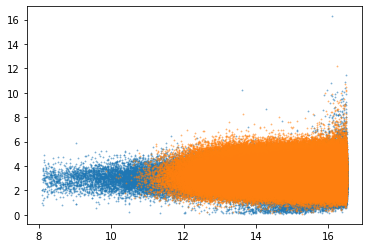

In [18]:
plt.scatter(stripe_table['Mean'],stripe_table['Eta_e'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['Eta_e'],s=1,alpha=0.5,marker='*')

In [27]:
tables = []
for i in range(0,9):
    tables.append(pd.read_csv('total_catalogues/w1_QSO_table%d.csv'%i))
table_QSO = pd.concat(tables)
# table_std_pho = pd.read_csv('total_catalogues/w1_std_pho_match_table0.csv')

In [ ]:
import pandas as pd
import glob
import os
import time

def one_turn_concat(table_list):
    start = time.time()
    result_table_list = []
    while len(table_list) > 1:
        sub_table1 = table_list.pop()
        sub_table2 = table_list.pop()
        result_table_list.append(pd.concat([sub_table1,sub_table2]))
    if len(table_list) == 1:
        result_table_list.append(table_list.pop())
    result_table_list.reverse()
    return result_table_list



In [ ]:

first_layer_names = glob.glob('[0-9][0-9][0-9]',root_dir='./mached_catalog')
first_layer_names.sort()
count=0
w1_para_tables = []
for name in first_layer_names:
    second_layer_names = glob.glob('[0-9][0-9][0-9][0-9]*',
                                root_dir='./mached_catalog/'+name)
    second_layer_names.sort()
    for long_name in second_layer_names:
        band='w1'        
        if True == os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_features.csv'):
            table = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+ band +'_features.csv')
            w1_para_tables.append(table)
            count+=1
            print("%f percent finished,count=%d"%(count/182.21, count))

In [ ]:
# sub_stage_table_list = []
# list_length = len(w1_para_tables)
# batch_size = 1000
# for i in range(0,int(list_length/batch_size)):       
#     sub_stage_table_list.append(pd.concat(w1_para_tables[0:batch_size]))
#     w1_para_tables = w1_para_tables[batch_size:]
# if len(w1_para_tables) > 0:
#     sub_stage_table_list.append(pd.concat(w1_para_tables))


In [ ]:
while len(w1_para_tables) > 10:
    w1_para_tables = one_turn_concat(w1_para_tables)

In [ ]:
for i in range(0,len(w1_para_tables)):
    w1_para_tables[i].to_csv('total_catalogues/w1_var_para_table%d.csv'%i)

In [ ]:

columns=['id_in_matched','ra','dec','median','mean_error', 'Mean','StetsonK', 'Eta_e', 'Std', 'Skew', 'SmallKurtosis', 'Con', 'Meanvariance']


In [ ]:
count = 0
id_list = []
for i in range(0,len(table)):
    line = table.iloc[i]
    if (line['Eta_e'] > 7 or line['StetsonK']>0.95) and line['Mean'] < 16:
        count+=1
        id_list.append(line['id_in_matched'])
        print (line['Eta_e'], line['StetsonK'])
print(count)

In [ ]:
print(id_list)

In [38]:
relibility_table = table[table['Mean']<16.5]
relibility_table = relibility_table.sample(500000)
len(relibility_table)

500000

In [29]:
relibility_table_std_pho = table_std_pho[table_std_pho['Mean']<16.5]
len(relibility_table_std_pho)

469859

In [30]:
print(len(table_QSO))
relibility_table_QSO = table_QSO[table_QSO['Mean']<16.5]
len(relibility_table_QSO)

779876


456276

In [59]:
table_QSO_type1 = relibility_table_QSO[relibility_table_QSO['TYPE']=='Q']
print(len(table_QSO_type1))

270560


In [63]:
table_QSO_type2 = relibility_table_QSO[relibility_table_QSO['TYPE']=='K']
print(len(table_QSO_type2))

1183


In [61]:
table_QSO_AGN = relibility_table_QSO[relibility_table_QSO['TYPE']=='A']
print(len(table_QSO_AGN))

19335


In [65]:
table_QSO_AGN2 = relibility_table_QSO[relibility_table_QSO['TYPE']=='N']
print(len(table_QSO_AGN2))

13513


In [67]:
table_BL_Lac = relibility_table_QSO[relibility_table_QSO['TYPE']=='B']
print(len(table_BL_Lac))

28


In [ ]:
relibility100_table = table[table['Mean']<15]
len(relibility100_table)

In [ ]:
relibility100_table_std_pho = table_std_pho[table_std_pho['Mean']<15]
len(relibility100_table_std_pho)

In [68]:
import numpy as np
median_QSO_type1 = np.array(table_QSO_type1['median'])
median_QSO_type2 = np.array(table_QSO_type2['median'])
median_AGN = np.array(table_QSO_AGN['median'])
median_AGN2 = np.array(table_QSO_AGN2['median'])
median_BL_Lac = np.array(table_BL_Lac['median'])

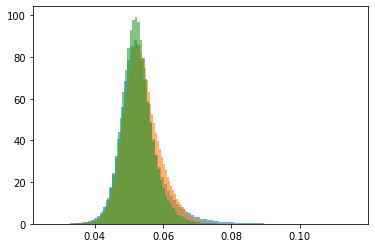

In [39]:
import matplotlib.pyplot as plt
import numpy as np
median = np.array(relibility_table['median'])
StetsonK = np.array(relibility_table['StetsonK'])
median_std_pho = np.array(relibility_table_std_pho['median'])
StetsonK_std_pho = np.array(relibility_table_std_pho['StetsonK'])
median_QSO = np.array(relibility_table_QSO['median'])
StetsonK_QSO = np.array(relibility_table_QSO['StetsonK'])
MedianStetsonK = np.divide(StetsonK,median)
MedianStetsonK_std_pho = np.divide(StetsonK_std_pho,median_std_pho)
MedianStetsonK_QSO = np.divide(StetsonK_QSO,median_QSO)
# plt.hist(np.array(table_test['StetsonK']),bins=100,density=True,alpha=0.6)
# plt.hist(np.array(table_test_std_pho['StetsonK']),bins=100,density=True,alpha=0.6)
plt.hist(MedianStetsonK,bins=100,density=True,alpha=0.6)
plt.hist(MedianStetsonK_std_pho,bins=100,density=True,alpha=0.6)
plt.hist(MedianStetsonK_QSO,bins=100,density=True,alpha=0.6)
plt.show()

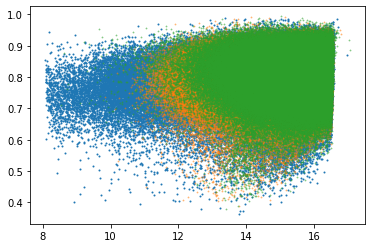

In [40]:
plt.scatter(median,StetsonK,s=1)
plt.scatter(median_std_pho,StetsonK_std_pho,s=1,alpha=0.5,marker='*')
plt.scatter(median_QSO,StetsonK_QSO,s=1,alpha=0.5,marker='*')

In [ ]:
# plt.style.use('_mpl-gallery-nogrid')
# from matplotlib import cm
# hist_array=plt.hist2d(median,StetsonK,range=((10,16),(0.6,1)),bins=(100,100),density=True,alpha=1,cmap=cm.Blues)
# hist_array_std_pho=plt.hist2d(median_std_pho,StetsonK_std_pho,range=((10,16),(0.6,1)),bins=(100,100),density=True,alpha=0.6,cmap=cm.Reds)

In [ ]:
# plt.style.use('_mpl-gallery')
# from matplotlib import cm
# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# ax.plot_surface(hist_array[1][1:101],hist_array[2][1:101],hist_array[0],alpha=0.6)
# ax.plot_surface(hist_array_std_pho[1][1:101],hist_array_std_pho[2][1:101],hist_array_std_pho[0],color='r',alpha=0.6)

In [ ]:
# plt.hist2d(median_std_pho,StetsonK_std_pho,range=((8,17),(0.5,1)),bins=(100,100))

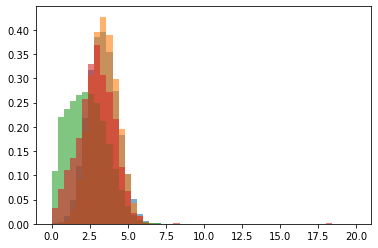

In [70]:
plt.hist(np.array(relibility_table['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.hist(np.array(relibility_table_std_pho['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.hist(np.array(relibility_table_QSO['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.hist(np.array(table_QSO_type2['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.show()

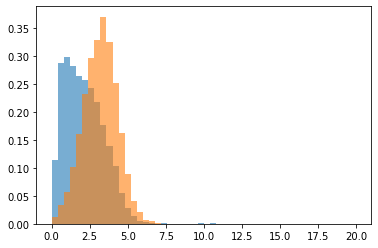

In [84]:
# plt.hist(np.array(relibility_table_QSO['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
# plt.hist(np.array(table_QSO_type2['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.hist(np.array(table_QSO_AGN['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.hist(np.array(table_QSO_AGN2['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
# plt.hist(np.array(table_BL_Lac['Eta_e']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.show()

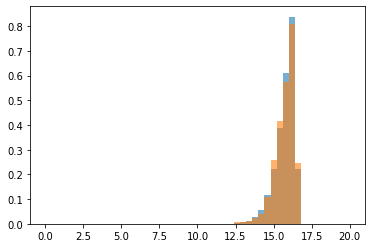

In [82]:
plt.hist(np.array(table_QSO_type1['median']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.hist(np.array(table_QSO_type2['median']),bins=50,density=True,alpha=0.6,range=(0,20))
plt.show()

In [ ]:
# plt.style.use('_mpl-gallery-nogrid')
# from matplotlib import cm
# hist_array=plt.hist2d(median,np.array(table['Eta_e']),range=((10,16),(0,8)),bins=(100,100),density=True,alpha=1,cmap=cm.Blues)
# hist_array_std_pho=plt.hist2d(median_std_pho,np.array(table_std_pho['Eta_e']),range=((10,16),(0,8)),bins=(100,100),density=True,alpha=0.6,cmap=cm.Reds)

In [ ]:
# plt.style.use('_mpl-gallery')
# from matplotlib import cm
# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# ax.plot_surface(hist_array[1][1:101],hist_array[2][1:101],hist_array[0],alpha=0.6,vmin=-0.1)
# ax.plot_surface(hist_array_std_pho[1][1:101],hist_array_std_pho[2][1:101],hist_array_std_pho[0],color='r',alpha=0.6,vmin=-0.1)

In [ ]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')


# hist, xedges, yedges = np.histogram2d(np.array(table['Eta_e']),median,range=((0,8),(12,15)),bins=(100,100),density=True)
# xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
# xpos = xpos.ravel()
# ypos = ypos.ravel()
# zpos = 0
# dx = dy = 0.5 * np.ones_like(zpos)
# dz = hist.ravel()
# ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average')

# plt.show()

In [ ]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')


# plt.show()

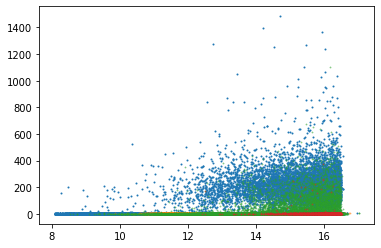

In [72]:
plt.scatter(median,np.array(relibility_table['Eta_e']),s=1)
plt.scatter(median_std_pho,np.array(relibility_table_std_pho['Eta_e']),s=1,alpha=0.5,marker='*')
plt.scatter(median_QSO,np.array(relibility_table_QSO['Eta_e']),s=1,alpha=0.5,marker='*')
plt.scatter(median_QSO_type2,np.array(table_QSO_type2['Eta_e']),s=1,alpha=0.5,marker='*')

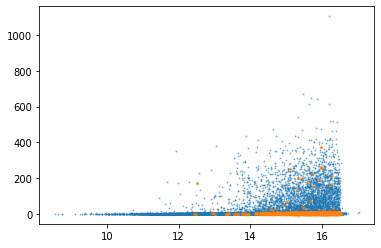

In [77]:
plt.scatter(median_QSO,np.array(relibility_table_QSO['Eta_e']),s=1,alpha=0.5,marker='*')

plt.scatter(median_QSO_type2,np.array(table_QSO_type2['Eta_e']),s=10,alpha=0.5,marker='*')

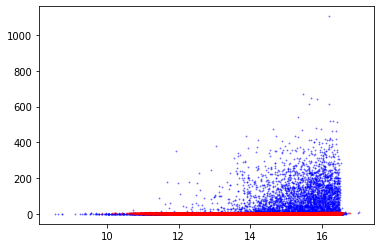

In [43]:
plt.scatter(median_QSO,np.array(relibility_table_QSO['Eta_e']),s=1,alpha=0.5,marker='*',color='b')
plt.scatter(median_std_pho,np.array(relibility_table_std_pho['Eta_e']),s=1,alpha=0.5,marker='*',color='r')


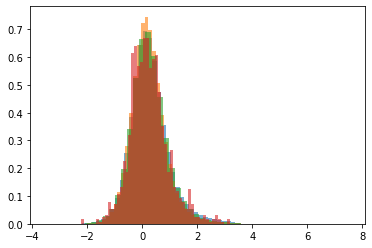

In [74]:
plt.hist(np.array(relibility_table['Skew']),bins=50,density=True,alpha=0.6)
plt.hist(np.array(relibility_table_std_pho['Skew']),bins=50,density=True,alpha=0.6)
plt.hist(np.array(relibility_table_QSO['Skew']),bins=50,density=True,alpha=0.6)
plt.hist(np.array(table_QSO_type2['Skew']),bins=50,density=True,alpha=0.6)

plt.show()

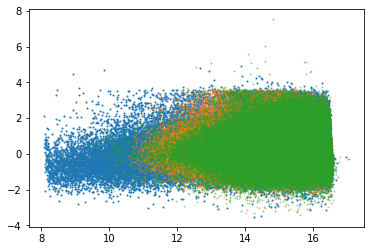

In [45]:
plt.scatter(median,np.array(relibility_table['Skew']),s=1)
plt.scatter(median_std_pho,np.array(relibility_table_std_pho['Skew']),s=1,alpha=0.5,marker='*')
plt.scatter(median_QSO,np.array(relibility_table_QSO['Skew']),s=1,alpha=0.5,marker='*')

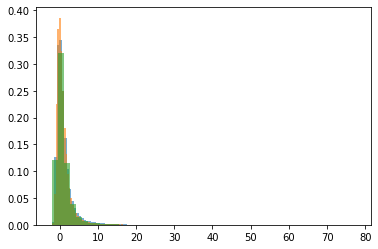

In [46]:
plt.hist(np.array(relibility_table['SmallKurtosis']),bins=50,density=True,alpha=0.6)
plt.hist(np.array(relibility_table_std_pho['SmallKurtosis']),bins=50,density=True,alpha=0.6)
plt.hist(np.array(relibility_table_QSO['SmallKurtosis']),bins=50,density=True,alpha=0.6)
plt.show()

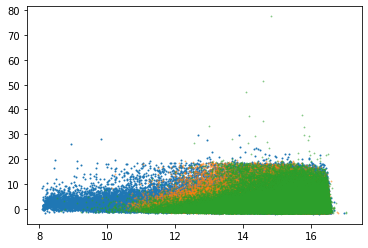

In [47]:
plt.scatter(median,np.array(relibility_table['SmallKurtosis']),s=1)
plt.scatter(median_std_pho,np.array(relibility_table_std_pho['SmallKurtosis']),s=1,alpha=0.5,marker='*')
plt.scatter(median_QSO,np.array(relibility_table_QSO['SmallKurtosis']),s=1,alpha=0.5,marker='*')

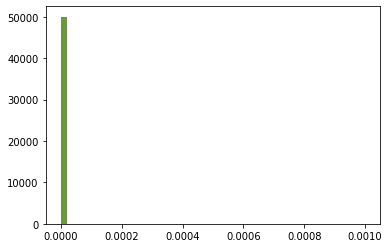

In [ ]:
plt.hist(np.array(relibility_table['Con']),bins=50,density=True,alpha=0.6,range=(0,0.001))
plt.hist(np.array(relibility_table_std_pho['Con']),bins=50,density=True,alpha=0.6,range=(0,0.001))
plt.hist(np.array(relibility_table_QSO['Con']),bins=50,density=True,alpha=0.6,range=(0,0.001))

plt.show()

In [ ]:
con_none_zero_table = relibility_table[relibility_table['Con']>0]
print(len(con_none_zero_table))

1550


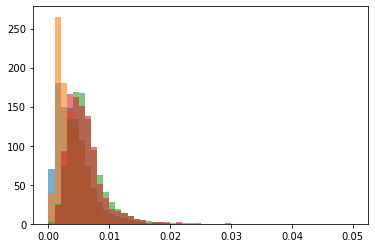

In [75]:
plt.hist(np.array(relibility_table['Meanvariance']),bins=50,density=True,range=(0,0.05),alpha=0.6)
plt.hist(np.array(relibility_table_std_pho['Meanvariance']),bins=50,density=True,range=(0,0.05),alpha=0.6)
plt.hist(np.array(relibility_table_QSO['Meanvariance']),bins=50,density=True,range=(0,0.05),alpha=0.6)
plt.hist(np.array(table_QSO_type2['Meanvariance']),bins=50,density=True,range=(0,0.05),alpha=0.6)

plt.show()

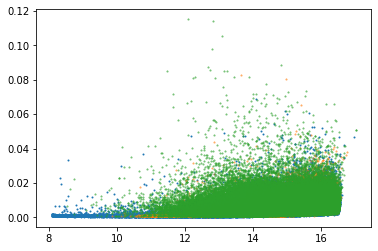

In [49]:
plt.scatter(median,np.array(relibility_table['Meanvariance']),s=1)
plt.scatter(median_std_pho,np.array(relibility_table_std_pho['Meanvariance']),s=2,alpha=0.5,marker='*')
plt.scatter(median_QSO,np.array(relibility_table_QSO['Meanvariance']),s=2,alpha=0.5,marker='*')

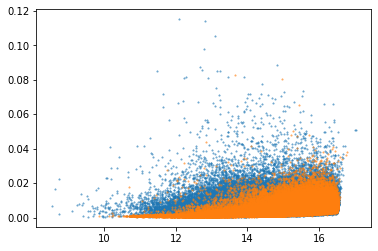

In [51]:
plt.scatter(median_QSO,np.array(relibility_table_QSO['Meanvariance']),s=2,alpha=0.5,marker='*')
plt.scatter(median_std_pho,np.array(relibility_table_std_pho['Meanvariance']),s=2,alpha=0.5,marker='*')


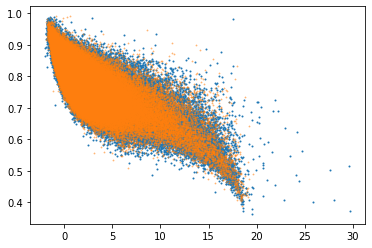

In [53]:
plt.scatter(relibility_table['SmallKurtosis'],StetsonK,s=1)
plt.scatter(relibility_table_std_pho['SmallKurtosis'],StetsonK_std_pho,s=1,alpha=0.5,marker='*')

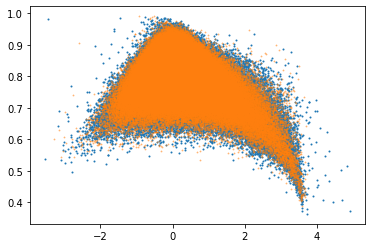

In [54]:
plt.scatter(relibility_table['Skew'],StetsonK,s=1)
plt.scatter(relibility_table_std_pho['Skew'],StetsonK_std_pho,s=1,alpha=0.5,marker='*')

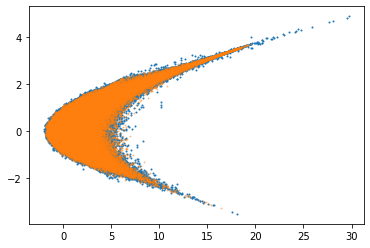

In [55]:
plt.scatter(relibility_table['SmallKurtosis'],relibility_table['Skew'],s=1)
plt.scatter(relibility_table_std_pho['SmallKurtosis'],relibility_table_std_pho['Skew'],s=1,alpha=0.5,marker='*')

In [ ]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# hist, xedges, yedges = np.histogram2d(np.array(table['Meanvariance']),median,range=((0,0.2),(10,18)),bins=(100,100),density=True)
# xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
# xpos = xpos.ravel()
# ypos = ypos.ravel()
# zpos = 0
# dx = dy = 0.5 * np.ones_like(zpos)
# dz = hist.ravel()
# ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average')

# plt.show()

In [ ]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')


# hist, xedges, yedges = np.histogram2d(np.array(table_std_pho['Meanvariance']),median_std_pho,range=((0,0.2),(10,18)),bins=(100,100),density=True)
# xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
# xpos = xpos.ravel()
# ypos = ypos.ravel()
# zpos = 0
# dx = dy = 0.5 * np.ones_like(zpos)
# dz = hist.ravel()
# ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average')

# plt.show()

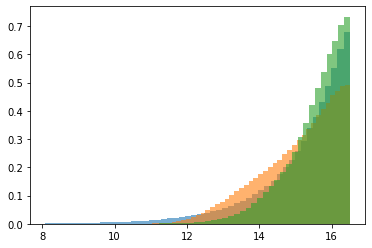

In [52]:
plt.hist(np.array(relibility_table['Mean']),bins=50,density=True,alpha=0.6)
plt.hist(np.array(relibility_table_std_pho['Mean']),bins=50,density=True,alpha=0.6)
plt.hist(np.array(relibility_table_QSO['Mean']),bins=50,density=True,alpha=0.6)

plt.show()

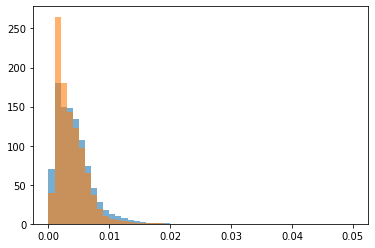

In [ ]:
median = np.array(relibility_table['median'])
std = np.array(relibility_table['Std'])
median_std_pho = np.array(relibility_table_std_pho['median'])
std_std_pho = np.array(relibility_table_std_pho['Std'])
Medianvariance = np.divide(std,median)
Medianvariance_std_pho = np.divide(std_std_pho,median_std_pho)
plt.hist(Medianvariance,bins=50,density=True,range=(0,0.05),alpha=0.6)
plt.hist(Medianvariance_std_pho,bins=50,density=True,range=(0,0.05),alpha=0.6)
plt.show()

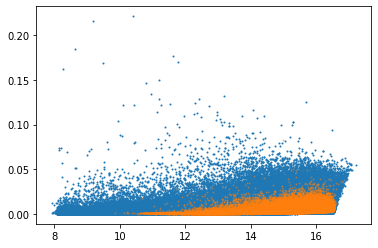

In [ ]:
plt.scatter(median,Medianvariance,s=1)
plt.scatter(median_std_pho,Medianvariance_std_pho,s=1,alpha=0.5,marker='*')

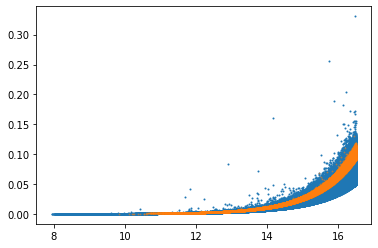

In [ ]:
mean = np.array(relibility_table['Mean'])
mean_error = np.array(relibility_table['mean_error'])
mean_std_pho = np.array(relibility_table_std_pho['Mean'])
mean_error_std_pho = np.array(relibility_table_std_pho['mean_error'])
plt.scatter(mean,mean_error,s=1)
plt.scatter(mean_std_pho,mean_error_std_pho,s=1,alpha=0.5,marker='*')

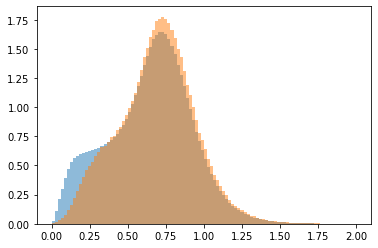

In [ ]:
plt.hist(np.divide(mean_error,std),bins=100,range=(0,2),alpha=0.5,density=True)
mean_error_std_pho = np.array(relibility_table_std_pho['mean_error'])
plt.hist(np.divide(mean_error_std_pho,std_std_pho),bins=100,range=(0,2),alpha=0.5,density=True)
plt.show()

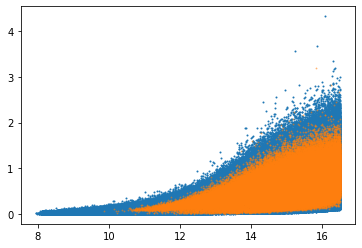

In [ ]:
plt.scatter(mean,np.divide(mean_error,std),s=1)
plt.scatter(mean_std_pho,np.divide(mean_error_std_pho,std_std_pho),s=1,alpha=0.5,marker='*')